# Demo: 2D image RI2FL

> 2D RI2FL demo


In [ ]:
#| default_exp tutorial_2

In [ ]:
from bioMONAI.data import *
from bioMONAI.transforms import *
from bioMONAI.core import *
from bioMONAI.core import Path
from bioMONAI.data import get_image_files, get_target, RandomSplitter
from bioMONAI.nets import BasicUNet, DynUNet
from bioMONAI.losses import *
from bioMONAI.metrics import *
from bioMONAI.datasets import aics_pipeline

from monai.utils import set_determinism

set_determinism(0)

In [ ]:
device = get_device()
print(device)

cpu


CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343995622/work/c10/cuda/CUDAFunctions.cpp:109.)


### Download Data

In [ ]:
image_path = "../_data/aics"
image_target_paths, data_manifest = aics_pipeline(6, image_path)

Loading manifest: 100%|██████████| 77165/77165 [00:01<00:00, 46.4k/s]


In [ ]:
data_manifest.to_csv(image_path + 'aics_dataset.csv')

### Create Dataloader

In [ ]:
bs, size = 16, 128

path = Path('../_data/Babesia/')
path_x = path/'RI'
path_y = path/'TRITC'


data_ops = {
    'blocks':       (BioImageBlock(cls=BioImageProject), BioImageBlock(cls=BioImage)),
    'get_items':    get_image_files,
    'get_y':        get_target(path_y, same_filename=False, signal_file_prefix='RI', target_file_prefix='TRITC'),
    'splitter':     RandomSplitter(valid_pct=0.2),
    'item_tfms':    [ScaleIntensity(minv=0.0, maxv=1.0),RandCrop2D(size), RandRot90(prob=0.5), RandFlip(prob=0.75)],
    'bs': bs,
}

data = get_dataloader(
    path_x, 
    show_summary=True,
    **data_ops,
    )

# print length of training and validation datasets
print('train images:', len(data.train_ds.items), '\nvalidation images:', len(data.valid_ds.items))

Setting-up type transforms pipelines
Found 275 items
2 datasets of sizes 220,55
Setting up Pipeline: BioImageProject.create -> Tensor2BioImage -- {}
Setting up Pipeline: get_target.<locals>.generate_target_path -> BioImage.create -> Tensor2BioImage -- {}

Building one sample
  Pipeline: BioImageProject.create -> Tensor2BioImage -- {}
    starting from
      ../_data/Babesia/RI/O11_RI_frame20.tiff
    applying BioImageProject.create gives
      BioImageProject of size 1x512x512
    applying Tensor2BioImage -- {} gives
      BioImageProject of size 1x512x512
  Pipeline: get_target.<locals>.generate_target_path -> BioImage.create -> Tensor2BioImage -- {}
    starting from
      ../_data/Babesia/RI/O11_RI_frame20.tiff
    applying get_target.<locals>.generate_target_path gives
      ../_data/Babesia/TRITC/O11_TRITC_frame20.tiff
    applying BioImage.create gives
      BioImage of size 1x512x512
    applying Tensor2BioImage -- {} gives
      BioImage of size 1x512x512

Final sample: (BioIma

Setting affine, but the applied meta contains an affine. This will be overwritten.


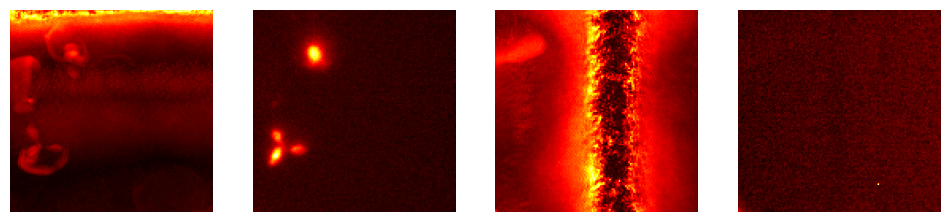

In [ ]:
data.show_batch(max_n=2, cmap='hot')

### Load and train a 2D model

In [ ]:
from bioMONAI.nets import Deeplab, DeeplabConfig

In [ ]:
config_2d = DeeplabConfig(
    dimensions=2,
    in_channels=1,  
    out_channels=1,
    backbone="resnet10",  
    aspp_dilations=[1, 6, 12, 18]
)
model = Deeplab(config_2d)
 
loss = MSSSIML1Loss(2, levels=2) #CombinedLoss(alpha=0, beta=0.5)
metrics = [SSIMMetric, MSELoss]

trainer = fastTrainer(data, model, loss_fn=loss, metrics=metrics, show_summary=False)

In [ ]:
trainer.fit_flat_cos(500)

In [ ]:
trainer.show_results(cmap='gray')

In [ ]:
# trainer.save('tmp-model')

### Test data 
Evaluate the performance of the selected model on unseen data.
It’s important to not touch this data until you have fine tuned your model to get an unbiased evaluation!